# 该脚本用于删除研究区域外的数据，包含以下功能：
### 1. 对研究区域进行旋转
### 2. 删除研究区域外的地震与台站

In [1]:
# 载入 PyTomoATT 数据处理函数

import pytomoatt as pta
import shutil

In [2]:
# 文件准备
import os
os.makedirs('figs', exist_ok=True)

output_dir = "traveltime_data"

fname = f"{output_dir}/src_rec_Turkey.tar.gz"
shutil.unpack_archive(fname, output_dir)

# 1. 读取数据并画图

2026-08-05 14:58:05,888 [SrcRec] WARNING: Found conflicting coordinates/elevations for 17 receiver(s):
staname    stla    stlo    stel  count
    AKK 36.1373 33.5486     1.0    782
    AKK 36.1435 33.5405     4.0    795
   ARPR 39.0929 38.3356  1522.0  17249
   ARPR 39.0929 38.3356  1537.0    245
    BNN 38.8520 35.8460  1350.0  19356
    BNN 38.8522 35.8472  1380.0    531
     BR 39.7074 33.6414  1346.9     17
     BR 39.7180 33.6173  1431.4     12
     BR 39.7253 33.6390  1414.8   2518
     BR 39.7254 33.6391  1437.2      4
     BR 39.7338 33.6180  1372.8     45
    BZK 41.9600 34.0035    70.0   2150
    BZK 41.9600 34.0035   158.0    284
    CSS 34.9611 33.3310   396.0    446
    CSS 34.9622 33.3306   396.0   4218
     CY 34.3349 34.5027 -2039.0      1
     CY 34.3393 34.5121 -2034.0     25
     CY 34.3466 34.5168 -2027.0      1
    GAZ 37.1721 37.2113   864.0  23380
    GAZ 37.1722 37.2097   992.0    524
    GEM 33.2105 35.6631   223.0     57
    GEM 33.2106 35.6632   218.0   1332


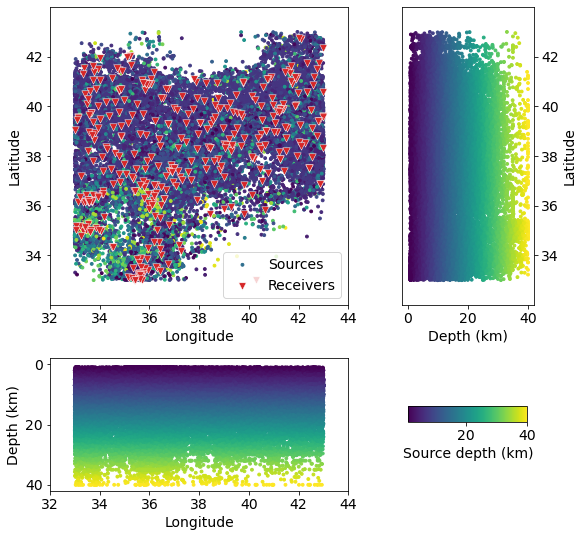

In [3]:
# 读取数据
sr = pta.SrcRec.read(f"{output_dir}/src_rec_Turkey.dat", conflicting_receiver_action="max_count")

# 数据画图（可选） fname = None 可以不保存图片
sr.plot(color_by='depth', fname="figs/step1_original_data.png");

# 2. 选定研究区域
1. 研究区域是 一个以 `(central_lon, central_lat)` 为中心的矩形，
2. y方向范围为 `[central_lat+lat1, central_lat+lat2]`， x方向范围为 `[central_lon+lon1, central_lon+lon2]`
3. 然后对研究区域进行顺时针旋转 `rotation_angle` 度

In [4]:
central_lat = 37.0      # 旋转中心纬度
central_lon = 37.0      # 旋转中心经度
rotation_angle = 45.0   # 顺时针旋转角度

lat1 = -2.0;    lat2 = 3.0;     # 研究区域 y 方向范围
lon1 = -1.3;    lon2 = 1.3;     # 研究区域 x 方向范围
dep1 =  0.5;    dep2 = 40.0;    # 研究区域深度方向范围

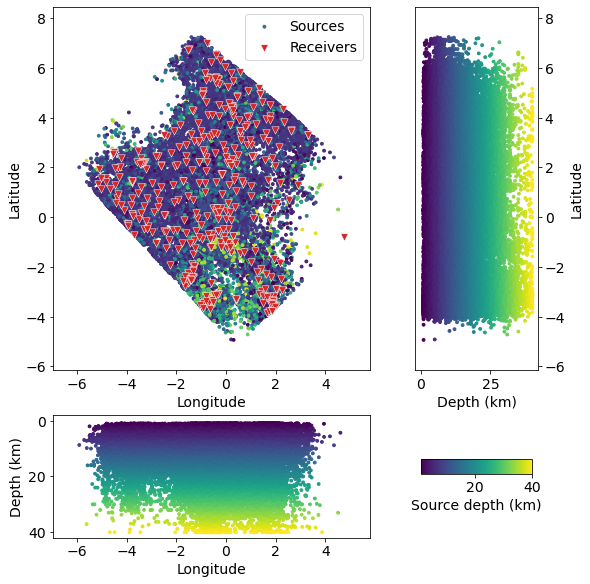

In [ ]:
# 如果研究区域是规则经纬度范围，无需旋转的话，可省略该步骤。

# 首先对所有地震与台站坐标进行旋转。满足：
# 0. 复制`sr`实例到`sr_rot`，避免修改原始数据。
# 1. 坐标原始地理位置 (central_lon,central_lat) 将变为经纬度 (0,0)。
# 2. 逆时针旋转 rotation_angle 角度。（PS：对数据逆时针旋转等价于研究区域顺时针选择）
sr_rot = sr.copy()
sr_rot.rotate(central_lat, central_lon, rotation_angle)

# 数据画图（可选）
sr_rot.plot(color_by='depth', fname="figs/step1_rotated_data.png");


2026-08-05 14:58:58,093 [SrcRec] INFO: src_points before selection: 144571
2026-08-05 14:58:58,094 [SrcRec] INFO: rec_points before selection: 1409519
2026-08-05 14:58:58,945 [SrcRec] INFO: Removed 420 duplicate receivers in rec_points
2026-08-05 14:58:59,068 [SrcRec] INFO: src_points after selection: (66333, 8)
2026-08-05 14:58:59,068 [SrcRec] INFO: rec_points after selection: (489641, 9)
2026-08-05 14:58:59,069 [SrcRec] INFO: src_points before selection: (66333, 8)
2026-08-05 14:58:59,069 [SrcRec] INFO: rec_points before selection: (489641, 9)
2026-08-05 14:58:59,837 [SrcRec] INFO: src_points after selection: (66333, 8)
2026-08-05 14:58:59,838 [SrcRec] INFO: rec_points after selection: (489641, 9)


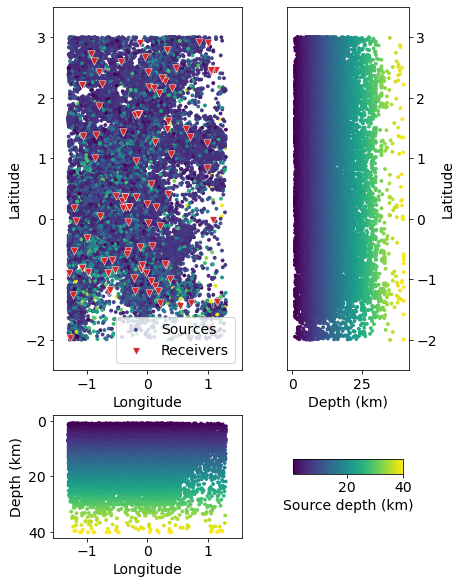

In [6]:
# 删除研究区域外的地震
sr_rot.select_by_box_region([lon1, lon2, lat1, lat2])

# 删除较大的深度数据
sr_rot.select_by_depth([dep1, dep2])

# 数据画图（可选）
sr_rot.plot(color_by='depth', fname="figs/step1_rotated_indom_data.png");

# 3. 数据输出

In [7]:
# 将数据输出到指定目录
out_path = "output_data"
os.makedirs(out_path, exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = f"{out_path}/step1_src_rec_indom.dat"
sr_rot.write(out_fname)

Writing src_rec file: 100%|██████████| 66333/66333 [00:00<00:00, 77698.56it/s]


# 4. （可选）还原到现实坐标，观察数据分布

Writing src_rec file: 100%|██████████| 66333/66333 [00:00<00:00, 77376.89it/s]


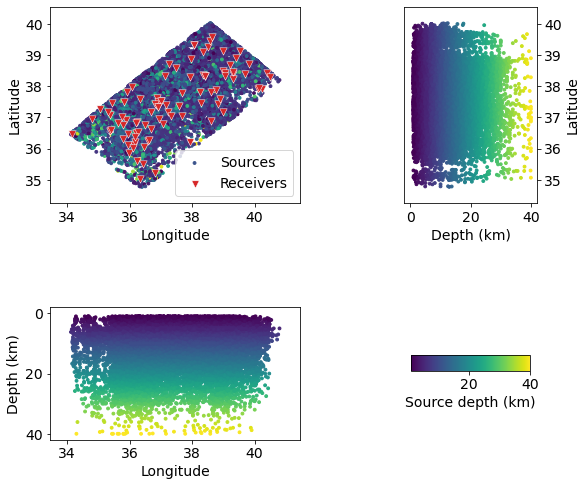

In [8]:
# 将数据旋转回原始地理位置
sr_rot.rotate(central_lon, central_lat, rotation_angle, reverse=True)

# 数据画图 （可选）
sr_rot.plot(color_by='depth', fname="figs/step1_indom_data.png")
# ffd.fig_ev_st_distribution_dep(ev_indom, st_indom, fname = "figs/step1_indom_data.png")

# 真实地震列表
out_fname_ev = f"{out_path}/step1_ev_list.dat"
sr_rot.write_sources(out_fname_ev)

# 真实台站列表
out_fname_st = f"{out_path}/step1_st_list.dat"
sr_rot.write_receivers(out_fname_st)

# 真实到时数据
out_fname_tt = f"{out_path}/step1_src_rec_data_norot.dat"
sr_rot.write(out_fname_tt)